In [ ]:
import uproot
import numpy as np
import mplhep as hep
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path
hep.style.use('CMS')

def get_hists(file: str):
    with uproot.open(file) as f:
        hists = { n.strip(';1') : (f[n].values(), np.arange(0,len(f[n].axis().edges()))) for n in f.classnames()}
    sig = hists.pop('ggHH_kl_1_kt_1_bbww')
    asimov = hists.pop('asimov')
    bkg_hists = { k:v for k,v in hists.items() if not k.startswith('ggHH')}
    return sig, bkg_hists

def plot_prefit_distributions(files: tuple, outdir: Path):
    signal_multiplier = 10
    for file in files:
        fig, ax = plt.subplots(figsize=(12, 10))
        sig, bkg_dict = get_hists(file)
        hep.histplot(list(bkg_dict.values()), ax=ax, histtype='fill', label=bkg_dict.keys(), stack=True, sort='y', alpha=0.8)
        hep.histplot((sig[0]*signal_multiplier, sig[1]), ax=ax, label=f'HH*{signal_multiplier}', lw=3, color='k')
        hep.cms.label("Preliminary", loc=0, ax=ax, year='2022', com='13.6')
        ax.set_ylabel('Events')
        ax.set_yscale('log')
        ax.set_xlim(0,sig[1][-1])
        ax.set_ylim(None, ax.get_ylim()[1]*10)
        ax.legend(ncol=(len(bkg_dict)+1)//2, loc="upper right")
        
        nn_node = file.stem.removesuffix('_score')
        get_official_name = lambda x: r't$\bar t$' if x == 'ttbar' else x
        ax.set_xlabel(rf"DNN {get_official_name(nn_node)} score bin / a.u.")

        pdf_path = outdir / f"prefit_{nn_node}.pdf"
        plt.savefig(pdf_path, format="pdf", bbox_inches="tight")

In [25]:
%config InlineBackend.figure_format = 'retina'

## Project: Disc_Study_New

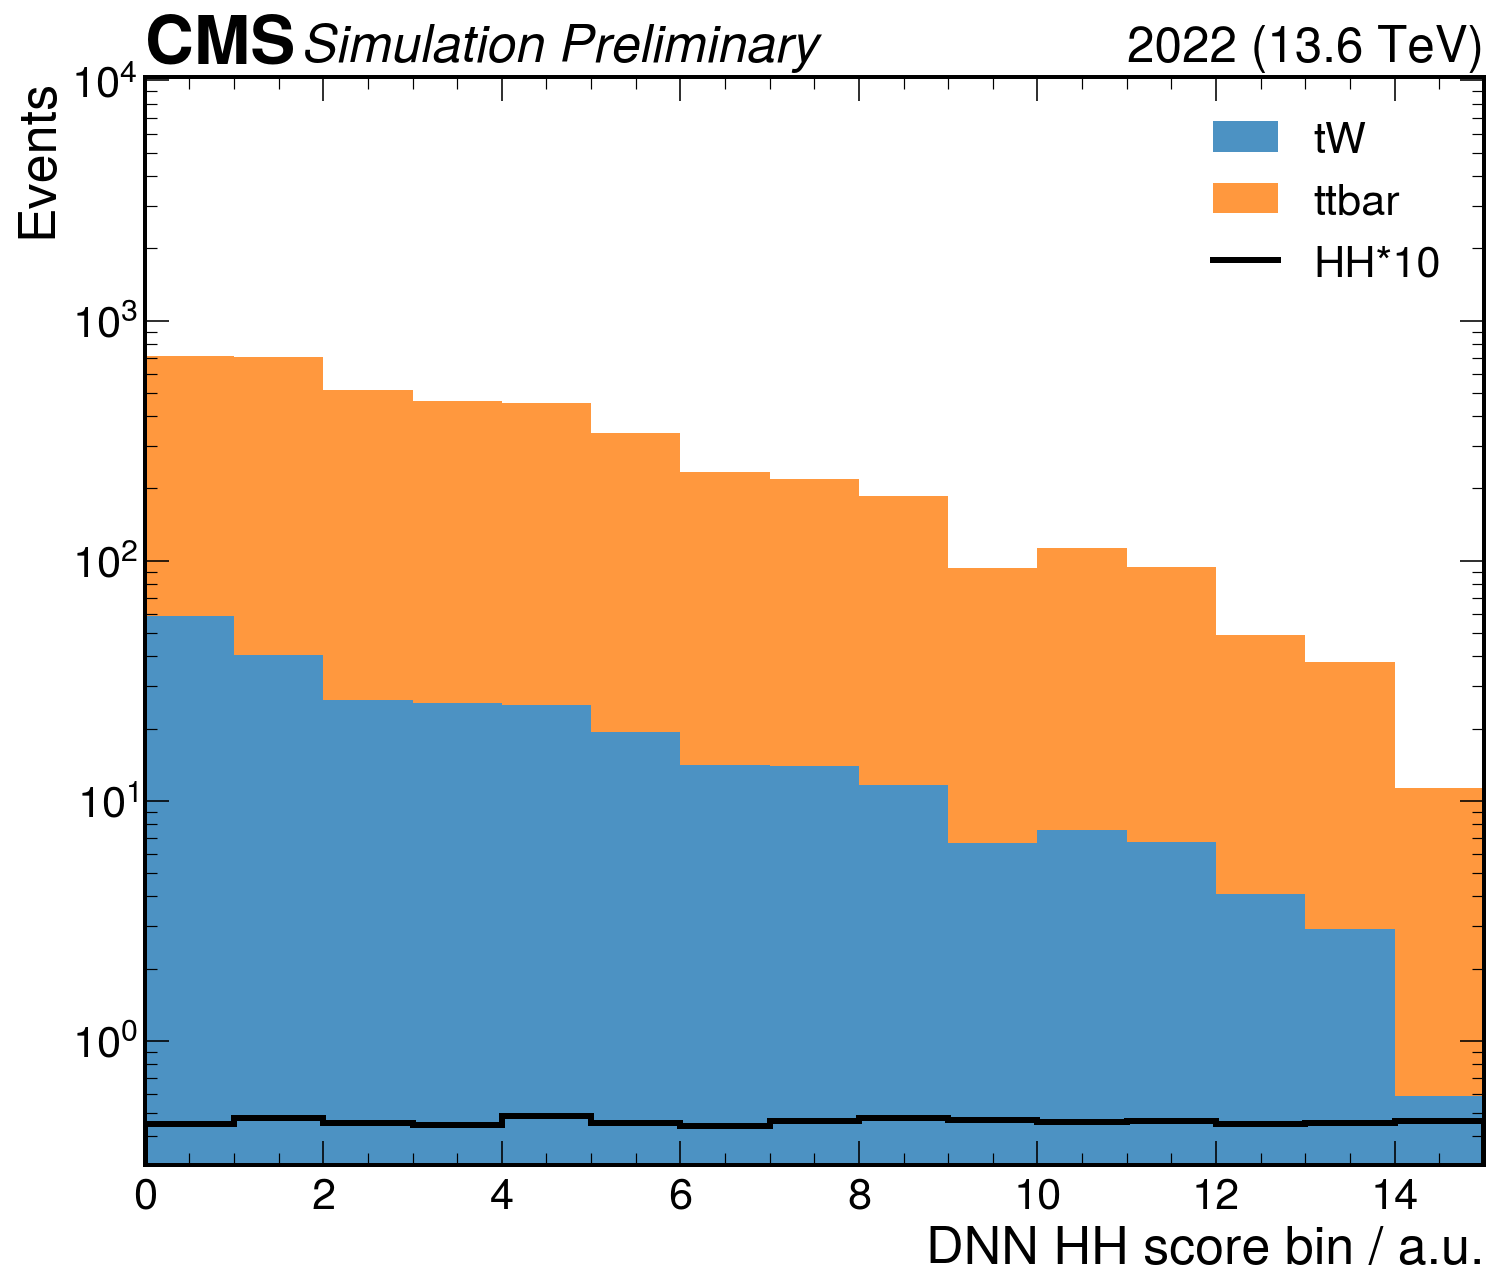

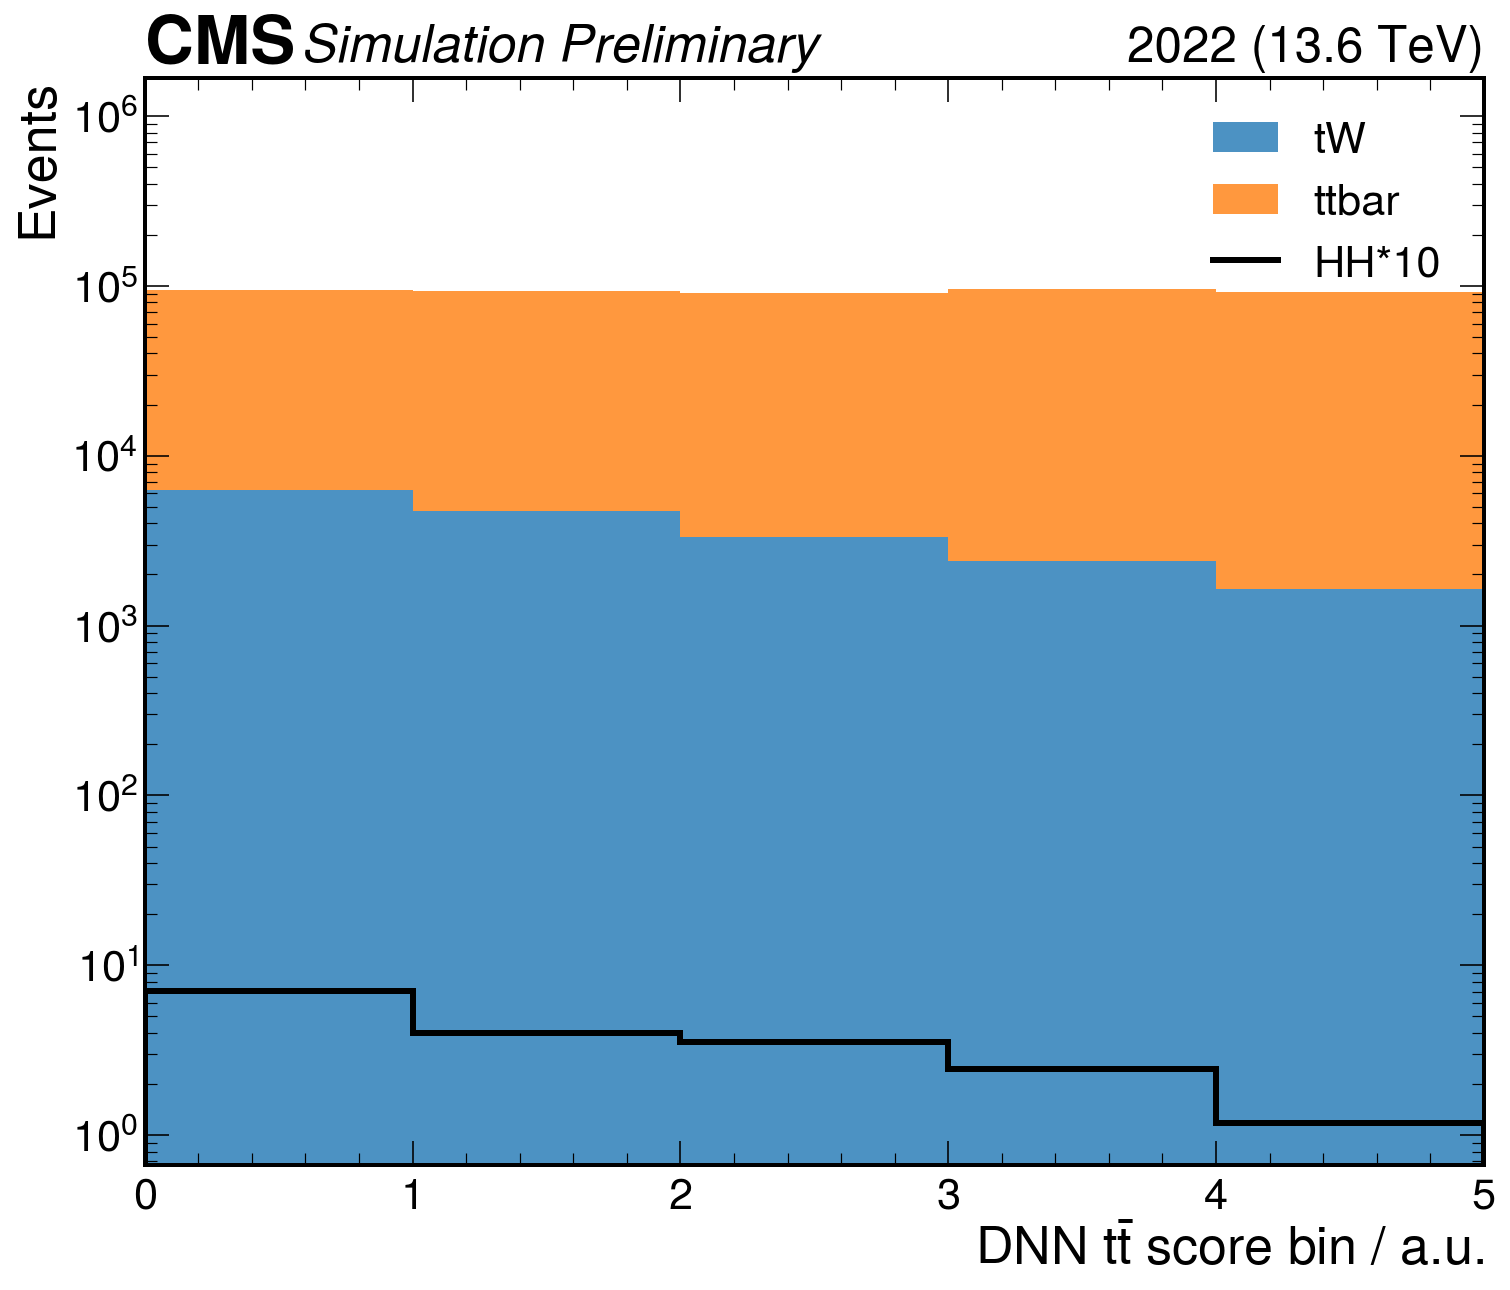

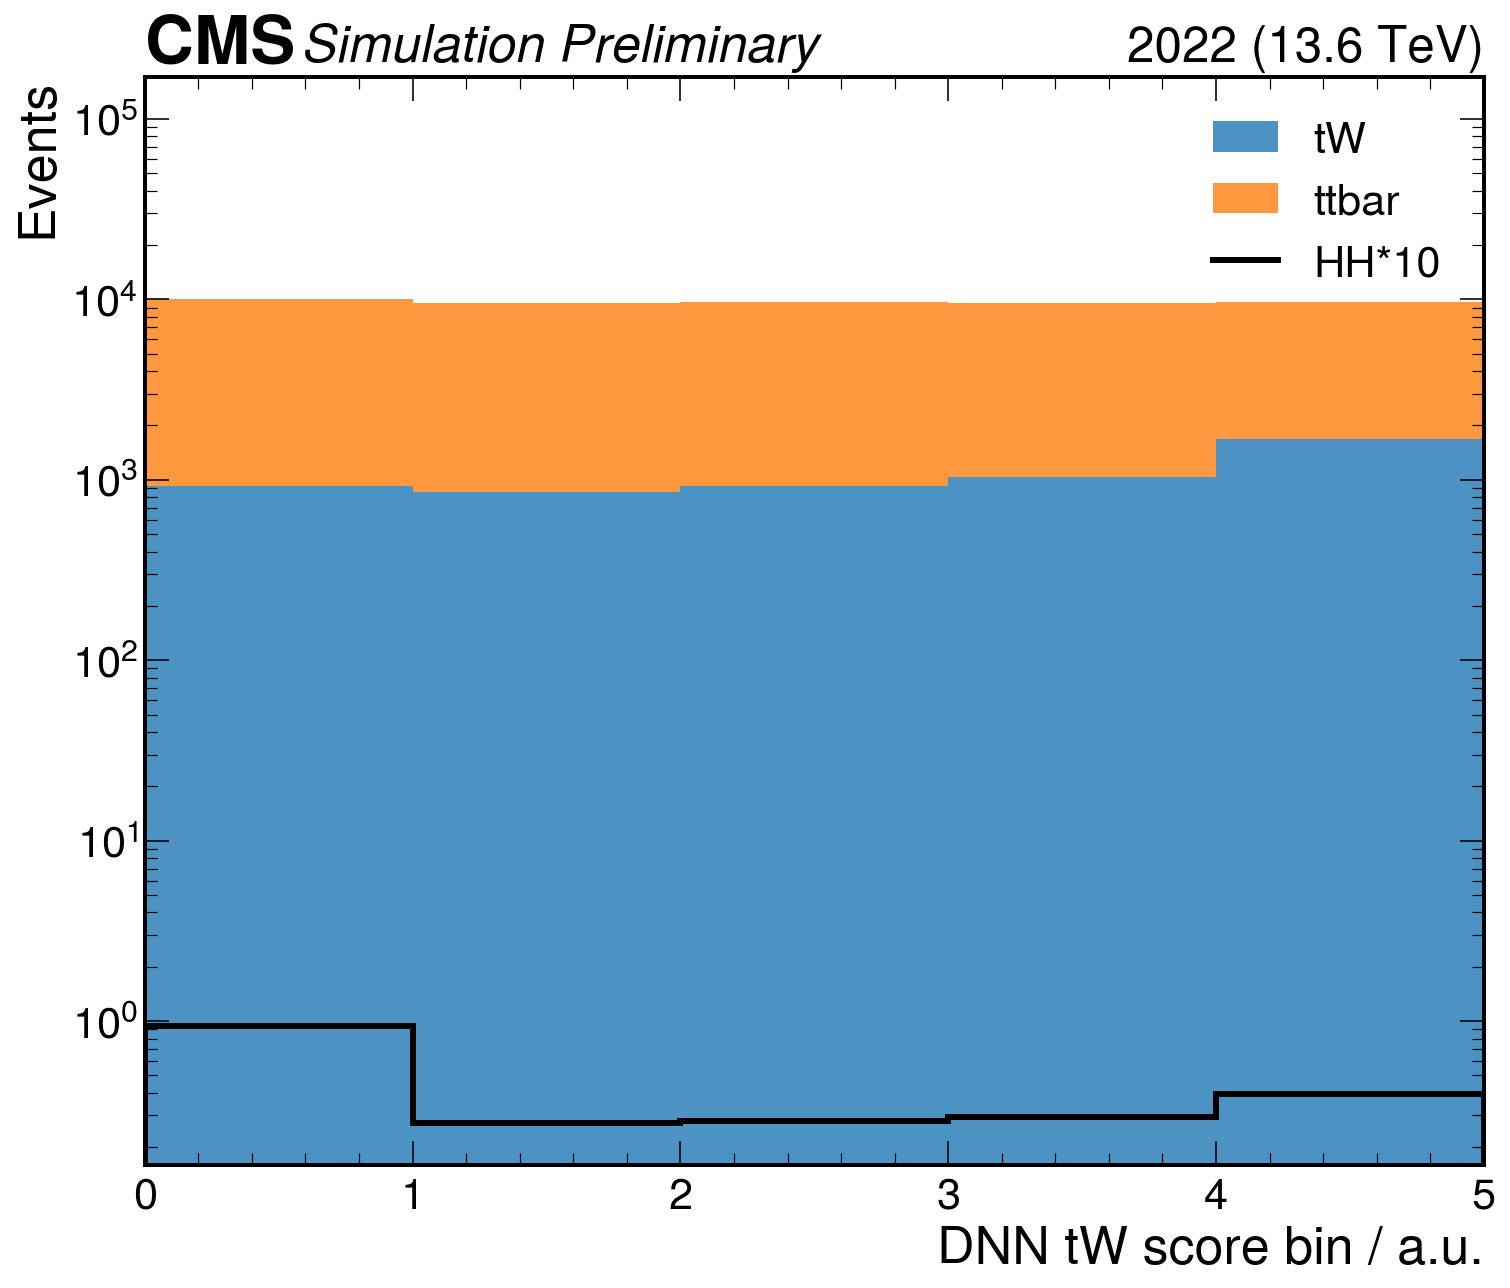

In [26]:
workdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/NNInf_even')
model_name = "multi_HH_ttbar_tW_lrs"
files = [
    workdir / 'fits_new' / model_name / '2022' / 'SL_4j_resolved' / 'HH'/ 'HH_score.root',
    workdir / 'fits_new' / model_name / '2022' / 'SL_4j_resolved' / 'ttbar'/ 'ttbar_score.root',
    workdir / 'fits_new' / model_name / '2022' / 'SL_4j_resolved' / 'tW'/ 'tW_score.root'
]
plot_prefit_distributions(files, workdir)

## Project: Disc_Study_Rep

Workdir: NN_even_LLRStudy_0327
Model name: multi_HH_ttbar_tW_LLRs


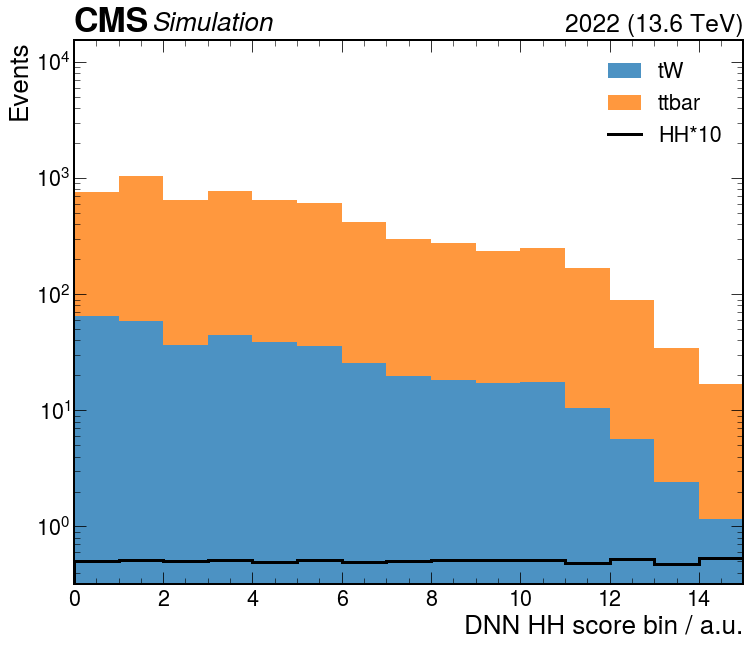

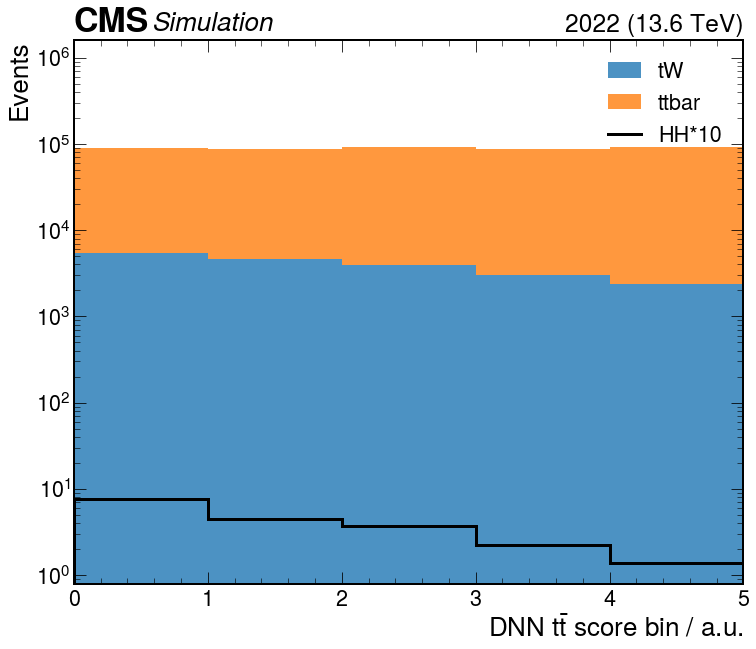

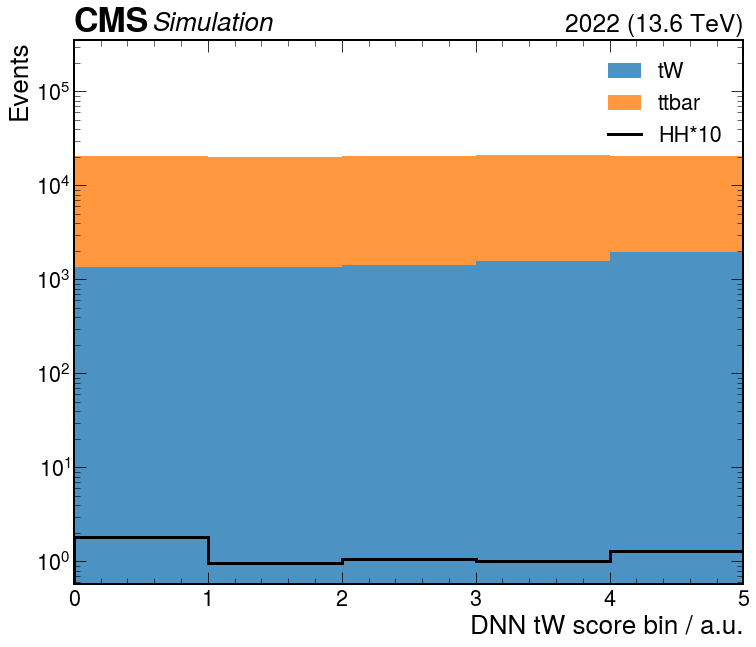

In [ ]:
workdir = 'NN_even_LLRStudy_0327'
model_name = "multi_HH_ttbar_tW_LLRs"
model_fit_dir = Path("/eos/user/a/anunezde/Z_OUTPUT_eos_archived/Era2022_0215_HHttbartW") / workdir / "fits" / model_name
signal_dc: str = model_fit_dir / "era_2022" / "SL_resolved_DNN_HH" / "scoreHH.root"
ttbar_dc: str = model_fit_dir / "era_2022" / "SL_resolved_DNN_ttbar" / "scorettbar.root"
tW_dc: str = model_fit_dir / "era_2022" / "SL_resolved_DNN_tW" / "scoretW.root"

data_files = [
    (signal_dc, r'DNN HH score bin / a.u.', 'HH'),
    (ttbar_dc, r'DNN t$\bar t$ score bin / a.u.', 'ttbar'),
    (tW_dc, r'DNN tW score bin / a.u.', 'tW')
]

print(f'Workdir: {workdir}')
print(f'Model name: {model_name}')

prefit_plots_dir = model_fit_dir / "era_2022" / "prefit_plots"
prefit_plots_dir.mkdir(parents=True, exist_ok=True)
for dc, xlabel, process in data_files:
    fig, ax = plt.subplots(figsize=(12, 10))
    sig, bkg_dict = get_hists(dc)
    hep.histplot(list(bkg_dict.values()), ax=ax, histtype='fill', label=bkg_dict.keys(), stack=True, sort='y', alpha=0.8)
    hep.histplot((sig[0]*signal_multiplier, sig[1]), ax=ax, label=f'HH*{signal_multiplier}', lw=3, color='k')
    hep.cms.label(loc=0, ax=ax, year='2022', com='13.6')
    ax.set_ylabel('Events')
    ax.set_yscale('log')
    ax.set_xlim(0,sig[1][-1])
    ax.set_ylim(None, ax.get_ylim()[1]*10)
    ax.legend(ncol=(len(bkg_dict)+1)//2)
    ax.set_xlabel(xlabel)

    pdf_path = prefit_plots_dir / f"DNN_{process}_prefit.pdf"
    plt.savefig(pdf_path, format="pdf", bbox_inches="tight")